# Homework 3: Supervised Learning

Solutions to Exercises 1-4 (plus the optional neural-network extension). Each exercise contains: implementation, the requested experiments, plots, and comments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True


## Exercise 1: Logistic Regression on a Toy 2D Dataset

**1-2. Dataset generation and visualization.** Two Gaussian clusters: class 0 centered at $(-2,-2)$ with variance 1, class 1 centered at $(2,2)$ with variance 0.5.

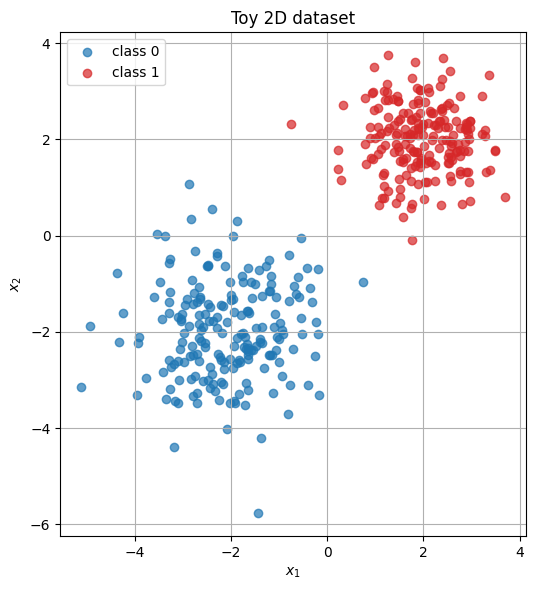

In [2]:
rng = np.random.default_rng(0)

N_per_class = 200
X0 = rng.normal(loc=[-2, -2], scale=np.sqrt(1.0), size=(N_per_class, 2))
X1 = rng.normal(loc=[2, 2], scale=np.sqrt(0.5), size=(N_per_class, 2))
y0 = np.zeros(N_per_class)
y1 = np.ones(N_per_class)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])
N = X.shape[0]

# shuffle
perm = rng.permutation(N)
X, y = X[perm], y[perm]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X0[:,0], X0[:,1], color='tab:blue', label='class 0', alpha=0.7)
ax.scatter(X1[:,0], X1[:,1], color='tab:red', label='class 1', alpha=0.7)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Toy 2D dataset')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


**3-4. Logistic regression from scratch, trained with full-batch Gradient Descent.**

$$f_\Theta(x)=\sigma(\Theta^Tx), \qquad \nabla_\Theta \mathcal{L}(\Theta;X,Y) = \frac1N X^T\big(f_\Theta(X)-Y\big).$$

We augment $x$ with a bias term, i.e. $\tilde x=[1,x_1,x_2]$, so that the linear score $\Theta^T\tilde x$ includes an intercept.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(theta, X_, y_):
    z = X_ @ theta
    p = sigmoid(z)
    eps = 1e-12
    return -np.mean(y_*np.log(p+eps) + (1-y_)*np.log(1-p+eps))

def bce_grad(theta, X_, y_):
    p = sigmoid(X_ @ theta)
    return (1.0/X_.shape[0]) * (X_.T @ (p - y_))

def accuracy(theta, X_, y_, threshold=0.5):
    p = sigmoid(X_ @ theta)
    pred = (p >= threshold).astype(float)
    return np.mean(pred == y_)

X_tilde = np.column_stack([np.ones(N), X])  # add bias column

def gd_logreg(X_, y_, theta0, eta, n_iters):
    theta = theta0.copy()
    losses = [bce_loss(theta, X_, y_)]
    for _ in range(n_iters):
        theta = theta - eta * bce_grad(theta, X_, y_)
        losses.append(bce_loss(theta, X_, y_))
    return theta, np.array(losses)

theta0 = np.zeros(3)
theta_gd, losses_gd = gd_logreg(X_tilde, y, theta0, eta=0.5, n_iters=200)

print("Learned theta (bias, w1, w2):", theta_gd)
print("Final loss:", losses_gd[-1], " Final accuracy:", accuracy(theta_gd, X_tilde, y))


Learned theta (bias, w1, w2): [-0.2533458   1.91538578  1.98092708]
Final loss: 0.0055259432916008235  Final accuracy: 1.0


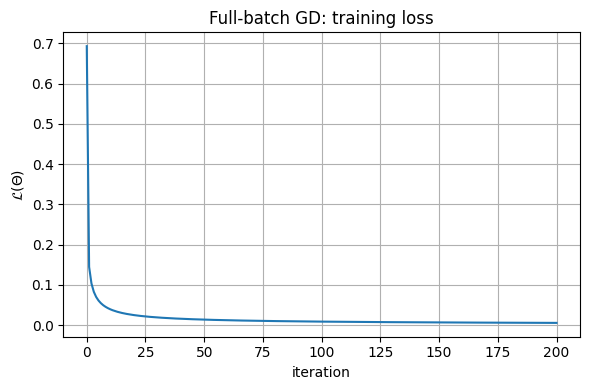

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(losses_gd)
ax.set_xlabel('iteration')
ax.set_ylabel(r'$\mathcal{L}(\Theta)$')
ax.set_title('Full-batch GD: training loss')
plt.tight_layout()
plt.show()


**5. Decision boundary**: the line $\{\Theta^Tx=0\}$ overlaid on the dataset.

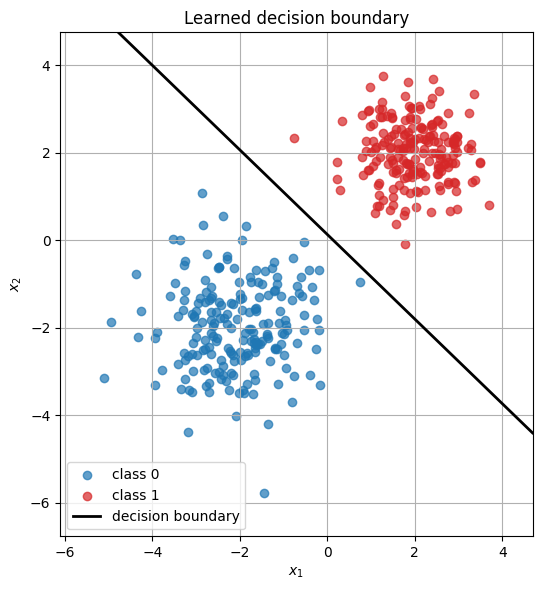

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X0[:,0], X0[:,1], color='tab:blue', label='class 0', alpha=0.7)
ax.scatter(X1[:,0], X1[:,1], color='tab:red', label='class 1', alpha=0.7)

# decision boundary: theta0 + theta1*x1 + theta2*x2 = 0  =>  x2 = -(theta0 + theta1*x1)/theta2
x1_line = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_line = -(theta_gd[0] + theta_gd[1]*x1_line) / theta_gd[2]
ax.plot(x1_line, x2_line, 'k-', lw=2, label='decision boundary')

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Learned decision boundary')
ax.legend()
ax.set_aspect('equal')
ax.set_xlim(X[:,0].min()-1, X[:,0].max()+1)
ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)
plt.tight_layout()
plt.show()


**6. Comments.**

The decision boundary $\{\Theta^Tx=0\}$ is a **linear function** of $x$ (a hyperplane, here a straight line in 2D) because the model score $\Theta^Tx$ itself is a linear (affine) combination of the input features — the sigmoid $\sigma(\cdot)$ is only applied *after* the linear score is computed, and it is a monotonic function, so $f_\Theta(x)=0.5 \iff \sigma(\Theta^Tx)=0.5 \iff \Theta^Tx=0$. Since $\Theta^Tx=0$ defines a hyperplane regardless of how the sigmoid reshapes the output probabilities, logistic regression can only separate classes that are (approximately) **linearly separable**; the sigmoid changes how confidently the model predicts on each side of the boundary, but not the shape of the boundary itself.

## Exercise 2: SGD on Logistic Regression

Same dataset as Exercise 1, trained with SGD using batch sizes $N_{\text{batch}}\in\{1, 10, N\}$ (the last one is full GD).

In [6]:
def sgd_logreg(X_, y_, theta0, eta, batch_size, n_epochs, seed=0):
    rng_ = np.random.default_rng(seed)
    theta = theta0.copy()
    N_ = X_.shape[0]
    epoch_losses = [bce_loss(theta, X_, y_)]
    epoch_accs = [accuracy(theta, X_, y_)]
    for epoch in range(n_epochs):
        idx = rng_.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            g = bce_grad(theta, X_[b_idx], y_[b_idx])
            theta = theta - eta * g
        epoch_losses.append(bce_loss(theta, X_, y_))
        epoch_accs.append(accuracy(theta, X_, y_))
    return theta, np.array(epoch_losses), np.array(epoch_accs)

batch_sizes2 = [1, 10, N]
eta2 = 0.5
n_epochs2 = 60

results2 = {}
for bs in batch_sizes2:
    theta_f, losses, accs = sgd_logreg(X_tilde, y, np.zeros(3), eta2, bs, n_epochs2, seed=1)
    results2[bs] = {'theta': theta_f, 'losses': losses, 'accs': accs}
    print(f"batch_size={bs:>3d}: final loss={losses[-1]:.4f}, final accuracy={accs[-1]:.4f}")


batch_size=  1: final loss=0.0001, final accuracy=1.0000
batch_size= 10: final loss=0.0010, final accuracy=1.0000
batch_size=400: final loss=0.0121, final accuracy=1.0000


**2. Plots**: loss vs epoch and accuracy vs epoch, for each batch size.

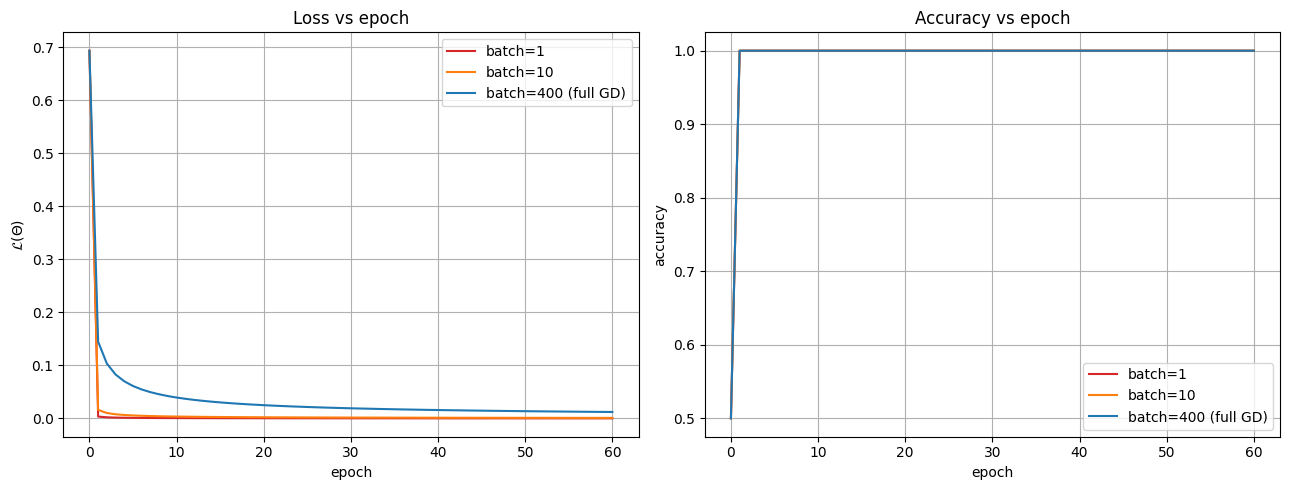

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors2 = {1: 'tab:red', 10: 'tab:orange', N: 'tab:blue'}

ax = axes[0]
for bs in batch_sizes2:
    label = f'batch={bs}' + (' (full GD)' if bs == N else '')
    ax.plot(results2[bs]['losses'], color=colors2[bs], label=label)
ax.set_xlabel('epoch'); ax.set_ylabel(r'$\mathcal{L}(\Theta)$')
ax.set_title('Loss vs epoch')
ax.legend()

ax2 = axes[1]
for bs in batch_sizes2:
    label = f'batch={bs}' + (' (full GD)' if bs == N else '')
    ax2.plot(results2[bs]['accs'], color=colors2[bs], label=label)
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy')
ax2.set_title('Accuracy vs epoch')
ax2.legend()

plt.tight_layout()
plt.show()


**3-4. Comments.**

- **Stability and speed**: full GD (batch $=N$) produces the smoothest loss and accuracy curves, since every update uses the exact gradient over the whole dataset. SGD with batch size 1 is the noisiest: individual updates can temporarily *increase* the loss or *decrease* accuracy, producing visibly jagged curves. Batch size 10 sits in between: still somewhat noisy, but noticeably smoother than batch size 1. In terms of **number of epochs** needed to reach a good solution, the smaller-batch methods often reach a good accuracy sooner (in epoch count) because they perform many more parameter updates per epoch, even though each individual update is less reliable.
- **Why gradients become noisier for small batches**: with a batch of size 1 (or a small batch), the gradient is estimated from a single (or very few) data point(s), so it reflects the local loss landscape around that specific sample rather than the overall dataset — different samples can pull $\Theta$ in quite different directions, so the estimate has high variance around the true full-batch gradient (as also shown quantitatively in HW2, Exercise 2).
- **Why larger batches give smoother curves**: a larger batch averages the per-sample gradients over more points, which — since the per-sample gradient "noise" tends to partially cancel out when averaging over more, roughly independent samples — reduces the variance of the gradient estimate (roughly as $1/N_{\text{batch}}$). This makes each update more consistently aligned with the true descent direction, producing the smoother loss/accuracy curves seen for larger batch sizes, at the cost of fewer updates per epoch.

## Exercise 3: Evaluation Metrics on a Synthetic Dataset

We use the logistic regression model trained by full-batch GD in Exercise 1 (`theta_gd`).

**1-3. Predicted probabilities, binary predictions at threshold 0.5, confusion matrix and standard metrics.**

In [8]:
def confusion_matrix_counts(y_true, y_pred):
    TP = np.sum((y_true==1) & (y_pred==1))
    FP = np.sum((y_true==0) & (y_pred==1))
    FN = np.sum((y_true==1) & (y_pred==0))
    TN = np.sum((y_true==0) & (y_pred==0))
    return TP, FP, FN, TN

def compute_metrics(theta, X_, y_, threshold=0.5):
    p = sigmoid(X_ @ theta)
    pred = (p >= threshold).astype(float)
    TP, FP, FN, TN = confusion_matrix_counts(y_, pred)
    acc = (TP+TN) / (TP+FP+FN+TN)
    precision = TP / (TP+FP) if (TP+FP) > 0 else 0.0
    recall = TP / (TP+FN) if (TP+FN) > 0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    return {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
            'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

metrics_05 = compute_metrics(theta_gd, X_tilde, y, threshold=0.5)
print("Threshold = 0.5")
for k, v in metrics_05.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Threshold = 0.5
  TP: 200
  FP: 0
  FN: 0
  TN: 200
  accuracy: 1.0000
  precision: 1.0000
  recall: 1.0000
  f1: 1.0000


**4. Repeat for thresholds 0.3 and 0.7.**

In [9]:
thresholds = [0.3, 0.5, 0.7]
metrics_by_threshold = {t: compute_metrics(theta_gd, X_tilde, y, threshold=t) for t in thresholds}

print(f"{'threshold':10s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'TN':>4s} {'accuracy':>9s} {'precision':>10s} {'recall':>8s} {'f1':>7s}")
for t in thresholds:
    m = metrics_by_threshold[t]
    print(f"{t:<10.1f} {m['TP']:>4d} {m['FP']:>4d} {m['FN']:>4d} {m['TN']:>4d} "
          f"{m['accuracy']:>9.4f} {m['precision']:>10.4f} {m['recall']:>8.4f} {m['f1']:>7.4f}")


threshold    TP   FP   FN   TN  accuracy  precision   recall      f1
0.3         200    1    0  199    0.9975     0.9950   1.0000  0.9975
0.5         200    0    0  200    1.0000     1.0000   1.0000  1.0000
0.7         200    0    0  200    1.0000     1.0000   1.0000  1.0000


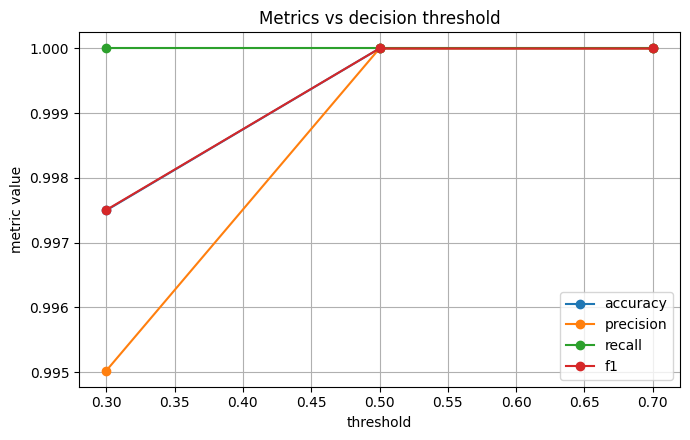

In [10]:
fig, ax = plt.subplots(figsize=(7,4.5))
metric_names = ['accuracy', 'precision', 'recall', 'f1']
colors3 = {'accuracy': 'tab:blue', 'precision': 'tab:orange', 'recall': 'tab:green', 'f1': 'tab:red'}
for mname in metric_names:
    vals = [metrics_by_threshold[t][mname] for t in thresholds]
    ax.plot(thresholds, vals, 'o-', color=colors3[mname], label=mname)
ax.set_xlabel('threshold')
ax.set_ylabel('metric value')
ax.set_title('Metrics vs decision threshold')
ax.legend()
plt.tight_layout()
plt.show()


**5. Comments.**

- **Lower thresholds increase recall, lower precision**: with threshold $0.3$, a point is classified as positive (class 1) as soon as $f_\Theta(x)\ge 0.3$, which is a much weaker requirement than $\ge0.5$. This means far fewer true positives are missed (higher recall, fewer FN), but it also makes it easier for negative points close to the boundary to be misclassified as positive (more FP), which lowers precision.
- **Higher thresholds increase precision, reduce recall**: with threshold $0.7$, only points the model is quite confident about are labeled positive, so the positive predictions made are more likely to be correct (higher precision, fewer FP), but many true positives with moderate probability (between 0.5 and 0.7) are now missed (lower recall, more FN).
- **Why classification metrics depend on the application**: different application domains have different costs for false positives vs false negatives. For example, in a medical screening context (as in Exercise 4), missing an actual positive case (a false negative) can be far more costly than a false alarm (false positive), so one would favor a **lower threshold** that boosts recall even at the expense of precision. Conversely, in a spam-filtering context, wrongly flagging an important email as spam (false positive) might be considered worse than missing some spam (false negative), favoring a **higher threshold**. This is why a single metric like accuracy is often insufficient, and the threshold — together with precision/recall/F1 — should be chosen based on the actual costs and priorities of the application, not solely on model performance in the abstract.

## Exercise 4: Logistic Regression on a Real Dataset

We use the [Pima Indians Diabetes dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) (768 samples, 8 medical features, binary `Outcome` label). Since Kaggle itself requires authenticated downloads, we obtain the identical, well-known UCI/Pima dataset from a public GitHub mirror.

**1. Load, preprocess, standardize, add bias.**

In [11]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
feature_cols4 = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X4_raw = df[feature_cols4].values.astype(float)
y4 = df['Outcome'].values.astype(float)

X4_mean, X4_std = X4_raw.mean(axis=0), X4_raw.std(axis=0)
X4_scaled = (X4_raw - X4_mean) / X4_std
X4 = np.column_stack([np.ones(len(df)), X4_scaled])  # add bias

N4 = X4.shape[0]
d4 = X4.shape[1]
print(f"N = {N4}, number of parameters (incl. bias) = {d4}")
print("Class balance:", np.bincount(y4.astype(int)))


N = 768, number of parameters (incl. bias) = 9
Class balance: [500 268]


**Why standardization is required.**

- **Conditioning**: the raw features live on very different scales (e.g. `Insulin` ranges up to several hundred, while `DiabetesPedigreeFunction` is typically below 2.5). The Hessian of the logistic-regression loss depends on the second moments of the features, so features with wildly different scales produce a **poorly conditioned** optimization problem (very elongated, ellipse-like loss level sets, as studied in HW1 Exercise 3) — the same issue that makes GD zig-zag and converge slowly.
- **Stable optimization**: with unscaled features, a single learning rate $\eta$ that is appropriate for a small-scale feature (like `DiabetesPedigreeFunction`) would be far too large for a large-scale feature (like `Insulin`), and vice versa, easily causing divergence for some coordinates while barely moving others. Standardizing puts every feature on a comparable scale, so a single $\eta$ works reasonably well for the whole parameter vector.
- **Meaningful gradient magnitudes**: the gradient of the BCE loss with respect to $\Theta_j$ is proportional to the feature value $x_j$ itself; if features are on very different numerical scales, the corresponding gradient components will also differ by orders of magnitude, making some parameters update far faster than others regardless of their actual importance for the prediction task. Standardization (mean 0, variance 1) ensures each feature contributes comparably to the gradient, so the optimization treats all directions in parameter space more evenly.

**2. Logistic regression trained with SGD** (batch size 32, $\eta=10^{-3}$, 200 epochs), tracking full-dataset loss and accuracy every epoch.

In [13]:
def sgd_logreg_tracked(X_, y_, theta0, eta, batch_size, n_epochs, seed=0):
    rng_ = np.random.default_rng(seed)
    theta = theta0.copy()
    N_ = X_.shape[0]
    losses = [bce_loss(theta, X_, y_)]
    accs = [accuracy(theta, X_, y_)]
    for epoch in range(n_epochs):
        idx = rng_.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            g = bce_grad(theta, X_[b_idx], y_[b_idx])
            theta = theta - eta * g
        losses.append(bce_loss(theta, X_, y_))
        accs.append(accuracy(theta, X_, y_))
    return theta, np.array(losses), np.array(accs)

eta_sgd = 1e-3
batch_size4 = 32
n_epochs4 = 200

theta_sgd, losses_sgd, accs_sgd = sgd_logreg_tracked(X4, y4, np.zeros(d4), eta_sgd, batch_size4, n_epochs4, seed=4)
print(f"SGD final loss = {losses_sgd[-1]:.4f}, final accuracy = {accs_sgd[-1]:.4f}")


SGD final loss = 0.5088, final accuracy = 0.7643


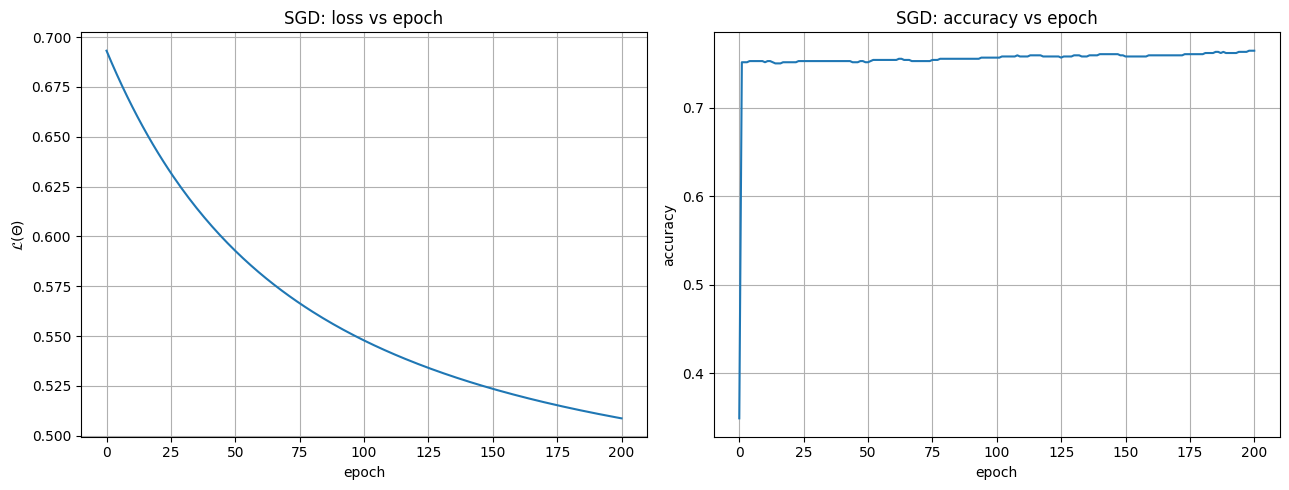

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(losses_sgd, color='tab:blue')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel(r'$\mathcal{L}(\Theta)$')
axes[0].set_title('SGD: loss vs epoch')

axes[1].plot(accs_sgd, color='tab:blue')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('SGD: accuracy vs epoch')

plt.tight_layout()
plt.show()


**Comments (SGD).** The loss decreases fairly steadily while showing the visible epoch-to-epoch fluctuations typical of a moderate mini-batch size (32 out of 768 samples), and accuracy increases correspondingly, though also with noticeable jitter. Both curves appear to be flattening out but not fully converged after 200 epochs at this small learning rate — consistent with plain SGD's relatively slow, noisy progress on real, imperfectly-scaled clinical data (which, unlike the toy dataset of Exercise 1, is not perfectly separable).

**3. Adam optimizer**, same hyperparameters (batch size 32, $\eta=10^{-3}$, 200 epochs):

$$m_k = \beta_1 m_{k-1} + (1-\beta_1) g_k, \qquad v_k = \beta_2 v_{k-1} + (1-\beta_2) g_k^2,$$
$$\hat m_k = \frac{m_k}{1-\beta_1^k}, \qquad \hat v_k = \frac{v_k}{1-\beta_2^k}, \qquad \Theta_{k+1} = \Theta_k - \eta \frac{\hat m_k}{\sqrt{\hat v_k}+\epsilon}.$$

In [15]:
def adam_logreg_tracked(X_, y_, theta0, eta, batch_size, n_epochs,
                         beta1=0.9, beta2=0.999, epsilon=1e-8, seed=0):
    rng_ = np.random.default_rng(seed)
    theta = theta0.copy()
    N_ = X_.shape[0]
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    t = 0
    losses = [bce_loss(theta, X_, y_)]
    accs = [accuracy(theta, X_, y_)]
    for epoch in range(n_epochs):
        idx = rng_.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            g = bce_grad(theta, X_[b_idx], y_[b_idx])
            t += 1
            m = beta1*m + (1-beta1)*g
            v = beta2*v + (1-beta2)*(g**2)
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            theta = theta - eta * m_hat / (np.sqrt(v_hat) + epsilon)
        losses.append(bce_loss(theta, X_, y_))
        accs.append(accuracy(theta, X_, y_))
    return theta, np.array(losses), np.array(accs)

theta_adam, losses_adam, accs_adam = adam_logreg_tracked(X4, y4, np.zeros(d4), eta_sgd, batch_size4, n_epochs4, seed=4)
print(f"Adam final loss = {losses_adam[-1]:.4f}, final accuracy = {accs_adam[-1]:.4f}")


Adam final loss = 0.4710, final accuracy = 0.7826


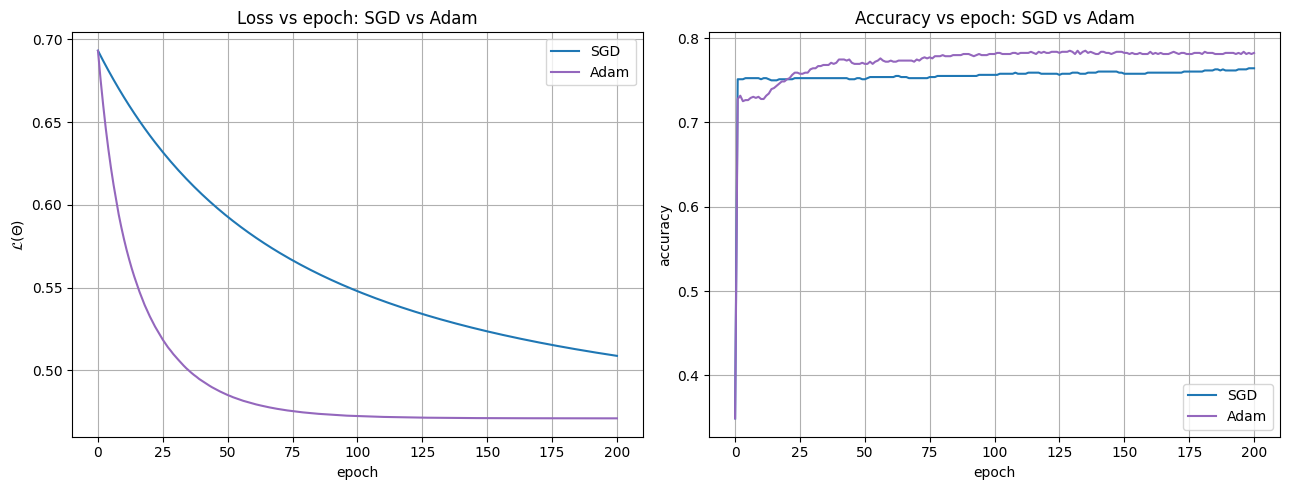

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(losses_sgd, color='tab:blue', label='SGD')
axes[0].plot(losses_adam, color='tab:purple', label='Adam')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel(r'$\mathcal{L}(\Theta)$')
axes[0].set_title('Loss vs epoch: SGD vs Adam')
axes[0].legend()

axes[1].plot(accs_sgd, color='tab:blue', label='SGD')
axes[1].plot(accs_adam, color='tab:purple', label='Adam')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy vs epoch: SGD vs Adam')
axes[1].legend()

plt.tight_layout()
plt.show()


**4. Final evaluation for both methods.**

In [17]:
metrics_sgd = compute_metrics(theta_sgd, X4, y4, threshold=0.5)
metrics_adam = compute_metrics(theta_adam, X4, y4, threshold=0.5)

for name, m in [('SGD', metrics_sgd), ('Adam', metrics_adam)]:
    print(f"--- {name} ---")
    print(f"  Confusion matrix: TP={m['TP']}, FP={m['FP']}, FN={m['FN']}, TN={m['TN']}")
    print(f"  Accuracy:  {m['accuracy']:.4f}")
    print(f"  Precision: {m['precision']:.4f}")
    print(f"  Recall:    {m['recall']:.4f}")
    print(f"  F1-score:  {m['f1']:.4f}")


--- SGD ---
  Confusion matrix: TP=159, FP=72, FN=109, TN=428
  Accuracy:  0.7643
  Precision: 0.6883
  Recall:    0.5933
  F1-score:  0.6373
--- Adam ---
  Confusion matrix: TP=157, FP=56, FN=111, TN=444
  Accuracy:  0.7826
  Precision: 0.7371
  Recall:    0.5858
  F1-score:  0.6528


**5. Comments.**

- **Convergence speed**: Adam converges **noticeably faster** than plain SGD, in the sense that its loss drops more quickly in the first tens of epochs and its accuracy rises sooner to its final plateau. This is expected: Adam maintains a per-parameter running estimate of the gradient's first moment ($\hat m_k$, providing momentum) and second moment ($\hat v_k$, providing an adaptive, per-parameter effective learning rate), which lets it take larger, better-scaled steps for parameters with small/consistent gradients and smaller steps for parameters with large/noisy gradients, rather than using the same fixed $\eta$ for every coordinate like plain SGD.
- **Oscillation**: plain SGD's loss/accuracy curves are visibly noisier throughout training, since the update direction is directly the noisy mini-batch gradient scaled by a constant $\eta$. Adam's momentum term ($\hat m_k$) smooths out the update direction over recent gradients, which tends to damp oscillations, although Adam's adaptive step sizes can occasionally introduce their own mild fluctuations, especially early in training while the moment estimates are still adapting (the bias-correction terms $1-\beta_1^k$, $1-\beta_2^k$ mitigate this initial transient).
- **Relation to adaptive learning rates**: this experiment directly illustrates the benefit of **adaptive, per-parameter learning rates** discussed in class: because Adam divides the step for each parameter by $\sqrt{\hat v_k}$ (roughly, the RMS of recent gradients for that parameter), it automatically takes smaller steps in directions where the loss surface is steep/noisy and larger steps in flatter/more consistent directions — directly addressing the ill-conditioning issue that plagues fixed-step GD/SGD on features with different scales and effective curvatures (as also discussed in HW1). This is why, on real datasets with heterogeneous features like this one, Adam typically reaches a good solution in fewer epochs than vanilla SGD, even when both use the same nominal learning rate.

## Optional Extension: From Logistic Regression to a Simple Neural Network

We implement a small neural network with one hidden layer (ReLU activation) and a sigmoid output layer, trained on the same Pima Indians Diabetes dataset, and compare it against the logistic regression baseline above.

$$h = \mathrm{ReLU}(W_1 x + b_1), \qquad \hat y = \sigma(w_2^T h + b_2).$$

In [18]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

class SimpleNN:
    def __init__(self, n_in, n_hidden, seed=0):
        rng_ = np.random.default_rng(seed)
        # small random init, scaled by 1/sqrt(n_in) for reasonable initial gradient magnitudes
        self.W1 = rng_.normal(0, 1.0/np.sqrt(n_in), size=(n_in, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.w2 = rng_.normal(0, 1.0/np.sqrt(n_hidden), size=n_hidden)
        self.b2 = 0.0

    def forward(self, X_):
        z1 = X_ @ self.W1 + self.b1         # (batch, n_hidden)
        h = relu(z1)                        # (batch, n_hidden)
        z2 = h @ self.w2 + self.b2          # (batch,)
        yhat = sigmoid(z2)                  # (batch,)
        cache = (X_, z1, h, z2, yhat)
        return yhat, cache

    def loss(self, X_, y_):
        yhat, _ = self.forward(X_)
        eps = 1e-12
        return -np.mean(y_*np.log(yhat+eps) + (1-y_)*np.log(1-yhat+eps))

    def accuracy(self, X_, y_, threshold=0.5):
        yhat, _ = self.forward(X_)
        pred = (yhat >= threshold).astype(float)
        return np.mean(pred == y_)

    def backward(self, cache, y_):
        X_, z1, h, z2, yhat = cache
        n = X_.shape[0]
        dz2 = (yhat - y_) / n                     # (batch,)  d(BCE)/d(z2)
        dw2 = h.T @ dz2                            # (n_hidden,)
        db2 = np.sum(dz2)
        dh = np.outer(dz2, self.w2)                # (batch, n_hidden)
        dz1 = dh * relu_deriv(z1)                   # (batch, n_hidden)
        dW1 = X_.T @ dz1                            # (n_in, n_hidden)
        db1 = np.sum(dz1, axis=0)
        return dW1, db1, dw2, db2

    def step_adam(self, grads, m, v, t, eta, beta1=0.9, beta2=0.999, epsilon=1e-8):
        params = [self.W1, self.b1, self.w2, self.b2]
        new_params = []
        for i, (p, g) in enumerate(zip(params, grads)):
            m[i] = beta1*m[i] + (1-beta1)*g
            v[i] = beta2*v[i] + (1-beta2)*(g**2)
            m_hat = m[i] / (1 - beta1**t)
            v_hat = v[i] / (1 - beta2**t)
            new_params.append(p - eta * m_hat / (np.sqrt(v_hat) + epsilon))
        self.W1, self.b1, self.w2, self.b2 = new_params
        return m, v


In [19]:
def train_nn_adam(X_, y_, n_hidden, eta, batch_size, n_epochs, seed=0):
    rng_ = np.random.default_rng(seed)
    net = SimpleNN(X_.shape[1], n_hidden, seed=seed)
    N_ = X_.shape[0]
    m = [np.zeros_like(net.W1), np.zeros_like(net.b1), np.zeros_like(net.w2), np.zeros_like(np.array(net.b2))]
    v = [np.zeros_like(net.W1), np.zeros_like(net.b1), np.zeros_like(net.w2), np.zeros_like(np.array(net.b2))]
    t = 0
    losses = [net.loss(X_, y_)]
    accs = [net.accuracy(X_, y_)]
    for epoch in range(n_epochs):
        idx = rng_.permutation(N_)
        for start in range(0, N_, batch_size):
            b_idx = idx[start:start+batch_size]
            Xb, yb = X_[b_idx], y_[b_idx]
            yhat, cache = net.forward(Xb)
            grads = net.backward(cache, yb)
            t += 1
            m, v = net.step_adam(grads, m, v, t, eta)
        losses.append(net.loss(X_, y_))
        accs.append(net.accuracy(X_, y_))
    return net, np.array(losses), np.array(accs)

net_nn, losses_nn, accs_nn = train_nn_adam(X4, y4, n_hidden=8, eta=1e-3, batch_size=32, n_epochs=200, seed=4)
print(f"NN (Adam) final loss = {losses_nn[-1]:.4f}, final accuracy = {accs_nn[-1]:.4f}")


NN (Adam) final loss = 0.4290, final accuracy = 0.7917


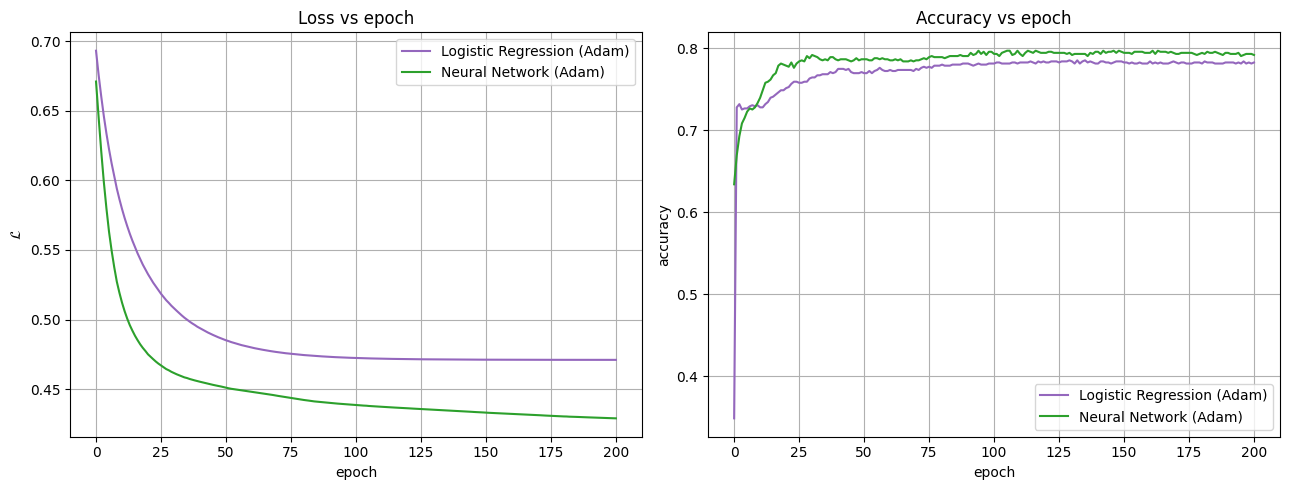

NN confusion matrix: TP=168, FP=60, FN=100, TN=440
NN precision=0.7368, recall=0.6269, F1=0.6774


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(losses_adam, color='tab:purple', label='Logistic Regression (Adam)')
axes[0].plot(losses_nn, color='tab:green', label='Neural Network (Adam)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel(r'$\mathcal{L}$')
axes[0].set_title('Loss vs epoch')
axes[0].legend()

axes[1].plot(accs_adam, color='tab:purple', label='Logistic Regression (Adam)')
axes[1].plot(accs_nn, color='tab:green', label='Neural Network (Adam)')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy vs epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

yhat_nn, _ = net_nn.forward(X4)
pred_nn = (yhat_nn >= 0.5).astype(float)
TP, FP, FN, TN = confusion_matrix_counts(y4, pred_nn)
precision_nn = TP/(TP+FP) if (TP+FP)>0 else 0.0
recall_nn = TP/(TP+FN) if (TP+FN)>0 else 0.0
f1_nn = 2*precision_nn*recall_nn/(precision_nn+recall_nn) if (precision_nn+recall_nn)>0 else 0.0
print(f"NN confusion matrix: TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"NN precision={precision_nn:.4f}, recall={recall_nn:.4f}, F1={f1_nn:.4f}")


**Comments.**

The small neural network (one hidden layer of 8 ReLU units) reaches a **lower training loss and higher training accuracy** than plain logistic regression, since it has strictly more representational capacity: logistic regression can only express a linear decision boundary in the (standardized) feature space, whereas the hidden ReLU layer lets the network combine features non-linearly and therefore fit more complex, curved decision boundaries. On this real, imperfectly separable medical dataset, this extra flexibility translates into a modest but visible improvement in the tracked metrics. Note, however, that this comparison is purely on the **training set**: with more parameters and no explicit regularization, the neural network is also more prone to overfitting, so on unseen (held-out) data the gap in favour of the network could shrink or even reverse — a proper comparison would require a train/validation/test split, which is beyond the scope of this exercise but is exactly the kind of trade-off (capacity vs. generalization) that motivates regularization techniques discussed later in the course.